# Ridge Logistic Regression xG Model

Trains and evaluates an L2-penalised (Ridge) logistic regression expected-goals model on StatsBomb open data.

Ridge logistic regression is a natural baseline for xG modelling:
- Outputs well-calibrated probabilities with no extra calibration step
- Coefficients are directly interpretable as feature effects on log-odds
- Regularisation prevents overfitting without requiring tree-specific tuning

Serie A 2015/16 is held out entirely as a test set — never used to fit the preprocessor,
tune `C`, or run cross-validation — so the final evaluation reflects genuine
generalisation to an unseen competition, not just CV performance on the same folds used
to select `C`.

**Pipeline summary:**
1. Load data, engineer features, and split off Serie A 2015/16 as a held-out test set
2. Preprocess — standardise numerics, encode categoricals, impute (fit on training shots only)
3. Tune regularisation strength `C` with Optuna (5-fold CV on training shots, log-loss)
4. Final evaluation — training-CV metrics vs true held-out test metrics (AUC, log-loss, Brier score)
5. Calibration curve (held-out test)
6. Coefficient analysis (training shots)
7. Distance-only baseline comparison (held-out test)
8. xG distribution (held-out test)
9. Save model to `outputs/`

In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from statsbombpy import sb

from src.features import create_xg_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('../outputs', exist_ok=True)

## 1. Data Loading and Feature Engineering

In [17]:
COMPETITIONS = [
    {'competition_id': 11, 'season_id': 27,  'label': 'La Liga 2015/16'},
    {'competition_id': 16, 'season_id': 4,   'label': 'Champions League 2018/19'},
    {'competition_id': 2,  'season_id': 27,  'label': 'Premier League 2015/16'},
    {'competition_id': 43, 'season_id': 106, 'label': 'World Cup 2022'},
    {'competition_id': 12, 'season_id': 27,  'label': 'Serie A 2015/16'},
]

# Held out entirely from preprocessing fits, hyperparameter tuning, and CV —
# used only as a final, untouched test set to check generalisation to an
# unseen competition, rather than relying solely on CV metrics that share
# folds with the hyperparameter search.
HOLDOUT_LABEL = 'Serie A 2015/16'

def load_competition(competition_id, season_id):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    events = pd.concat(
        [sb.events(match_id=mid).assign(match_id=mid) for mid in matches['match_id']],
        ignore_index=True,
    )
    return matches['match_id'].tolist(), events

all_events = []
match_id_to_label = {}
for comp in COMPETITIONS:
    print(f"Loading {comp['label']}…")
    match_ids, events = load_competition(comp['competition_id'], comp['season_id'])
    for mid in match_ids:
        match_id_to_label[mid] = comp['label']
    all_events.append(events)

events_df = pd.concat(all_events, ignore_index=True)
xg_df = create_xg_features(events_df)

shots = xg_df[xg_df['is_penalty'] == 0].copy().reset_index(drop=True)
shots['competition_label'] = shots['match_id'].map(match_id_to_label)

is_holdout = shots['competition_label'] == HOLDOUT_LABEL
shots_train = shots[~is_holdout].reset_index(drop=True)
shots_test = shots[is_holdout].reset_index(drop=True)

train_labels = ', '.join(c['label'] for c in COMPETITIONS if c['label'] != HOLDOUT_LABEL)
print(f"\nTotal shots (excl. penalties): {len(shots):,}")
print(f"  Train ({train_labels}): {len(shots_train):,} shots, "
      f"{shots_train['is_goal'].mean():.1%} goal rate")
print(f"  Held-out test ({HOLDOUT_LABEL}): {len(shots_test):,} shots, "
      f"{shots_test['is_goal'].mean():.1%} goal rate")

Loading La Liga 2015/16…
Loading Champions League 2018/19…
Loading Premier League 2015/16…
Loading World Cup 2022…
Loading Serie A 2015/16…

Total shots (excl. penalties): 30,224
  Train (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022): 20,347 shots, 9.9% goal rate
  Held-out test (Serie A 2015/16): 9,877 shots, 8.7% goal rate


In [37]:
print(shots_train)

       match_id          team_name  minute  period  is_goal  shot_x  shot_y  \
0         22912  Tottenham Hotspur       9       1        0    91.9    43.1   
1         22912          Liverpool      16       1        0    90.2    59.3   
2         22912          Liverpool      20       1        0    95.2    47.2   
3         22912          Liverpool      21       1        0   113.0    59.5   
4         22912          Liverpool      37       1        0    98.4    20.4   
...         ...                ...     ...     ...      ...     ...     ...   
20342   3869685          Argentina     107       4        0   114.4    52.0   
20343   3869685          Argentina     107       4        1   116.6    43.0   
20344   3869685             France     115       4        0   101.4    26.6   
20345   3869685             France     122       4        0   103.7    45.1   
20346   3869685          Argentina     122       4        0   110.8    41.6   

       distance_to_goal  shot_angle  centrality  ..

## 2. Preprocessing

Ridge regression is sensitive to feature scale, so numeric features are standardised with `StandardScaler`. This is the key preprocessing difference from the tree-based XGBoost model.

In [18]:
CATEGORICAL_FEATURES = ['shot_body_part', 'shot_technique', 'previous_event_type']

NUMERIC_FEATURES = [
    'distance_to_goal', 'shot_angle', 'centrality',
    'in_penalty_area', 'in_six_yard_box',
    'shot_first_time', 'shot_under_pressure',
    'num_defenders_in_frame', 'num_teammates_in_frame',
    'distance_to_nearest_defender', 'num_defenders_between_shot_and_goal',
    'goalkeeper_distance_to_goal', 'goalkeeper_distance_to_shooter',
    'previous_event_was_pass', 'previous_event_was_carry',
    'previous_event_same_team', 'previous_event_distance',
    'is_late_game', 'is_extra_time',
]

TARGET = 'is_goal'

numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    # Standardisation is required: Ridge penalises large coefficients uniformly,
    # so features on different scales would be penalised unequally without scaling.
    ('scale',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
], remainder='drop')

# Only training-competition shots are used to fit the preprocessor, tune C,
# and run CV. The held-out test set is transformed later with the fitted
# preprocessor but never used to fit anything.
X = shots_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = shots_train[TARGET].values

X_test = shots_test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = shots_test[TARGET].values

X_transformed = preprocessor.fit_transform(X)
ohe_feature_names = (
    preprocessor.named_transformers_['cat']['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
ALL_FEATURE_NAMES = NUMERIC_FEATURES + ohe_feature_names
print(f"Feature matrix (train): {X_transformed.shape[0]:,} shots × {X_transformed.shape[1]} features")

Feature matrix (train): 20,347 shots × 54 features


## 3. Hyperparameter Tuning (Optuna)

`C` is the inverse regularisation strength — smaller `C` = stronger Ridge penalty.

In [38]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    C = trial.suggest_float('C', 1e-4, 1e3, log=True)
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            penalty='l2', C=C, solver='lbfgs',
            max_iter=1000, random_state=42,
        )),
    ])
    fold_losses = []
    for train_idx, val_idx in CV.split(X, y):
        model.fit(X.iloc[train_idx], y[train_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        fold_losses.append(log_loss(y[val_idx], proba))
    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

best_C = study.best_params['C']
print(f"\nBest log-loss: {study.best_value:.4f}\n")

# Search-space bounds are read back from Optuna's own trial distributions
# (not re-declared) so this table can't drift out of sync with objective().
tuning_summary = pd.DataFrame([
    {'Parameter': name, 'Min': dist.low, 'Max': dist.high, 'Best': study.best_params[name]}
    for name, dist in study.best_trial.distributions.items()
]).set_index('Parameter')
print("Hyperparameter search space vs. selected value:")
print(tuning_summary.to_string())

  0%|          | 0/40 [00:00<?, ?it/s]


Best log-loss: 0.2607

Hyperparameter search space vs. selected value:
              Min     Max      Best
Parameter                          
C          0.0001  1000.0  0.208566


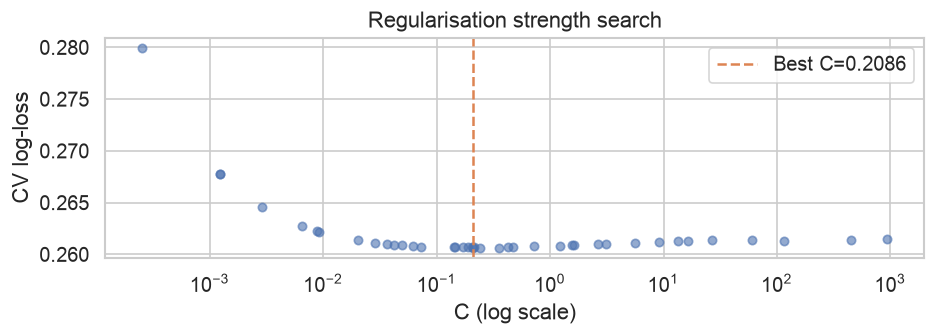

In [20]:
# C search landscape — shows how sensitive performance is to regularisation strength
trials_df = study.trials_dataframe().sort_values('params_C')

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(trials_df['params_C'], trials_df['value'], 'o', alpha=0.6, ms=5, color='#4C72B0')
ax.axvline(best_C, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Best C={best_C:.4f}')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV log-loss')
ax.set_title('Regularisation strength search')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Final Evaluation — Training CV vs Held-Out Test

The training-CV metrics reuse the same folds used during the `C` search, so they carry
a mild optimistic bias. The held-out test metrics come from Serie A 2015/16, a
competition never touched during tuning or CV, and are the more trustworthy estimate of
real generalisation. All later sections (calibration, baseline comparison, xG
distribution) use the held-out test predictions.

In [21]:
final_model = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2', C=best_C, solver='lbfgs',
        max_iter=1000, random_state=42,
    )),
])

# Training-CV probabilities — out-of-fold, but C was selected using these same
# folds, so this remains a mildly optimistic estimate.
oof_proba = cross_val_predict(final_model, X, y, cv=CV, method='predict_proba')[:, 1]

train_cv_metrics = {
    'ROC-AUC':     roc_auc_score(y, oof_proba),
    'Log-loss':    log_loss(y, oof_proba),
    'Brier score': brier_score_loss(y, oof_proba),
}

# Fit on all training-competition shots, then predict on the untouched
# Serie A 2015/16 held-out set — a genuine test of generalisation.
final_model.fit(X, y)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'ROC-AUC':     roc_auc_score(y_test, test_proba),
    'Log-loss':    log_loss(y_test, test_proba),
    'Brier score': brier_score_loss(y_test, test_proba),
}

metrics = test_metrics  # headline evaluation from here on is the held-out test set

comparison_cv_test = pd.DataFrame({
    'Training CV (OOF)':            train_cv_metrics,
    'Held-out test (Serie A 2015/16)': test_metrics,
}).round(4)

print("Evaluation metrics — training CV vs true held-out test:")
print(comparison_cv_test.to_string())

Evaluation metrics — training CV vs true held-out test:
             Training CV (OOF)  Held-out test (Serie A 2015/16)
ROC-AUC                 0.8035                           0.8181
Log-loss                0.2607                           0.2329
Brier score             0.0742                           0.0650


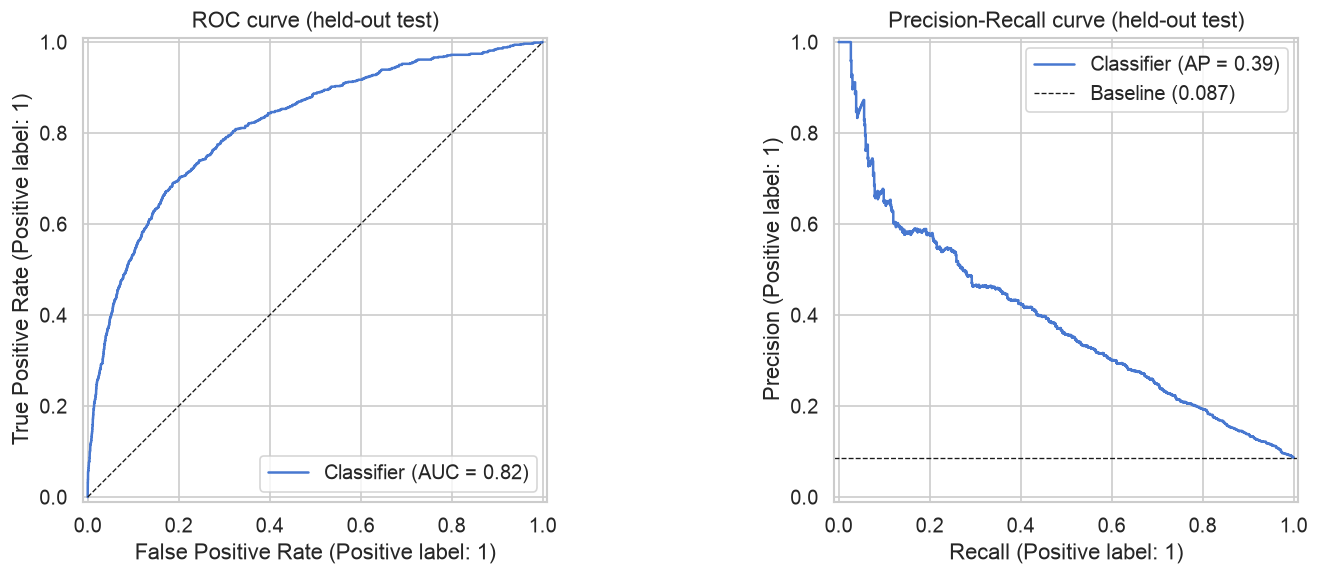

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC curve (held-out test)')

PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[1])
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=0.8, label=f'Baseline ({y_test.mean():.3f})')
axes[1].legend()
axes[1].set_title('Precision-Recall curve (held-out test)')

plt.tight_layout()
plt.show()

## 5. Calibration

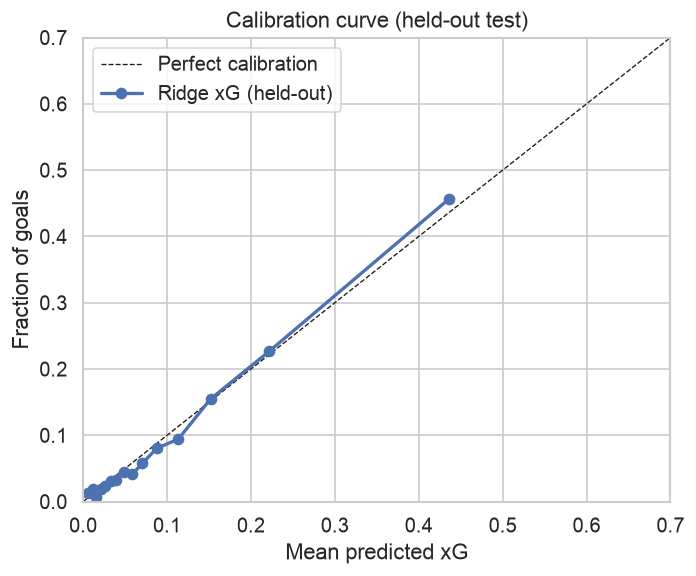

Expected Calibration Error (ECE, held-out test): 0.0071


In [23]:
fraction_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=15, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 'o-', color='#4C72B0', linewidth=2, markersize=6, label='Ridge xG (held-out)')
ax.set_xlabel('Mean predicted xG')
ax.set_ylabel('Fraction of goals')
ax.set_title('Calibration curve (held-out test)')
ax.legend()
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(test_proba, bins) - 1
ece = sum(
    (np.sum(bin_ids == b) / len(y_test)) * abs(y_test[bin_ids == b].mean() - test_proba[bin_ids == b].mean())
    for b in range(len(bins) - 1) if np.sum(bin_ids == b) > 0
)
print(f"Expected Calibration Error (ECE, held-out test): {ece:.4f}")

## 6. Coefficient Analysis

Unlike tree-based models, logistic regression coefficients are directly interpretable: each coefficient is the change in log-odds of a goal per one-standard-deviation increase in that feature (for numeric features after scaling).

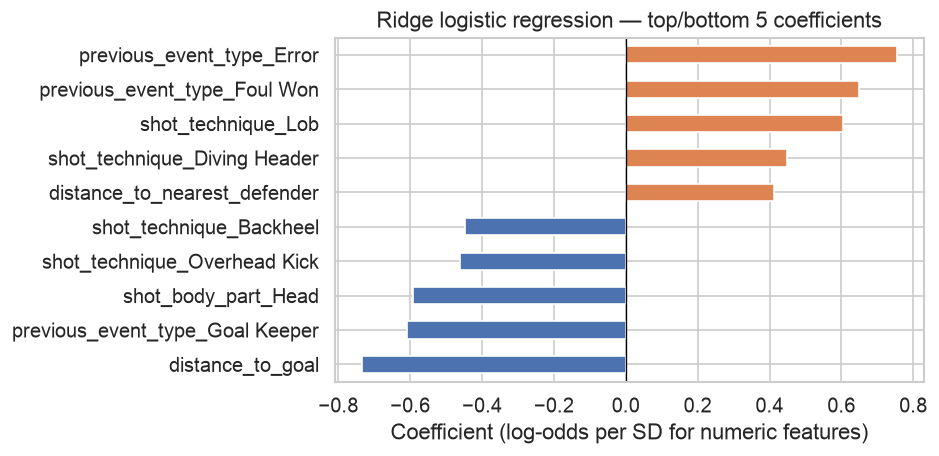

In [32]:
# final_model was already fit on the training-competition shots in the
# evaluation cell above; coefficients reflect that fit.
coefs = pd.Series(
    final_model.named_steps['clf'].coef_[0],
    index=ALL_FEATURE_NAMES,
).sort_values()

# Show top and bottom 5 coefficients
n = 5
coef_display = pd.concat([coefs.head(n), coefs.tail(n)]).drop_duplicates()
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_display]

fig, ax = plt.subplots(figsize=(8, 4))
coef_display.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds per SD for numeric features)')
ax.set_title(f'Ridge logistic regression — top/bottom {n} coefficients')
plt.tight_layout()
plt.show()

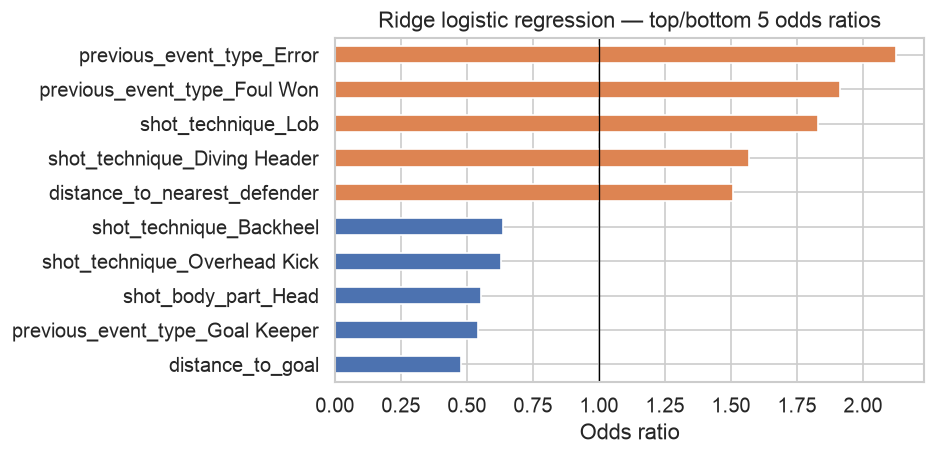

Top 10 goal-increasing features (OR > 1):
previous_event_type_Error             2.127
previous_event_type_Foul Won          1.913
shot_technique_Lob                    1.829
shot_technique_Diving Header          1.568
distance_to_nearest_defender          1.509
shot_angle                            1.502
shot_body_part_Right Foot             1.492
shot_body_part_Left Foot              1.478
previous_event_type_Block             1.474
previous_event_type_Foul Committed    1.451

Top 10 goal-decreasing features (OR < 1):
distance_to_goal                       0.479
previous_event_type_Goal Keeper        0.544
shot_body_part_Head                    0.553
shot_technique_Overhead Kick           0.630
shot_technique_Backheel                0.638
previous_event_type_Duel               0.643
previous_event_type_Clearance          0.688
shot_body_part_Other                   0.700
centrality                             0.727
num_defenders_between_shot_and_goal    0.741


In [34]:
# Odds ratios — easier to communicate: OR > 1 increases goal probability, OR < 1 decreases it
odds_ratios = np.exp(coefs)
or_display = pd.concat([odds_ratios.head(n), odds_ratios.tail(n)]).drop_duplicates().sort_values()

colors_or = ['#DD8452' if v > 1 else '#4C72B0' for v in or_display]
fig, ax = plt.subplots(figsize=(8, 4))
or_display.plot.barh(ax=ax, color=colors_or, edgecolor='white')
ax.axvline(1, color='black', linewidth=0.8)
ax.set_xlabel('Odds ratio')
ax.set_title(f'Ridge logistic regression — top/bottom {n} odds ratios')
plt.tight_layout()
plt.show()

print("Top 10 goal-increasing features (OR > 1):")
print(odds_ratios.sort_values(ascending=False).head(10).round(3).to_string())
print("\nTop 10 goal-decreasing features (OR < 1):")
print(odds_ratios.sort_values().head(10).round(3).to_string())

## 7. Baseline Comparison

A distance-only logistic regression is the simplest meaningful xG model. Comparing
against it shows how much the additional features contribute. Fit on the same training
shots as the full model and evaluated on the same held-out Serie A 2015/16 test set for
a fair comparison.

In [26]:
baseline_model = Pipeline([
    ('pre', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ])),
    ('clf', LogisticRegression(penalty='l2', C=best_C, solver='lbfgs',
                               max_iter=1000, random_state=42)),
])

X_baseline_train = shots_train[['distance_to_goal', 'shot_angle']]
X_baseline_test = shots_test[['distance_to_goal', 'shot_angle']]

baseline_model.fit(X_baseline_train, y)
baseline_test_proba = baseline_model.predict_proba(X_baseline_test)[:, 1]

baseline_metrics = {
    'ROC-AUC':     roc_auc_score(y_test, baseline_test_proba),
    'Log-loss':    log_loss(y_test, baseline_test_proba),
    'Brier score': brier_score_loss(y_test, baseline_test_proba),
}

comparison = pd.DataFrame({
    'Distance + angle only': baseline_metrics,
    'Ridge (all features)':  metrics,
}).T.round(4)

print("Model comparison (held-out test):")
print(comparison.to_string())

Model comparison (held-out test):
                       ROC-AUC  Log-loss  Brier score
Distance + angle only   0.7619    0.2562       0.0712
Ridge (all features)    0.8181    0.2329       0.0650


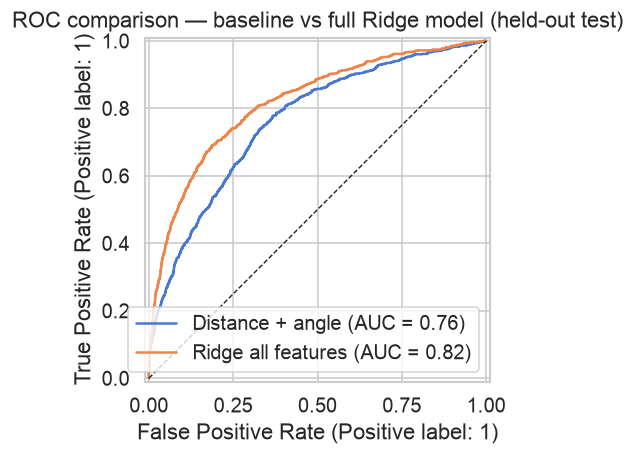

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))

RocCurveDisplay.from_predictions(
    y_test, baseline_test_proba, ax=ax,
    name=f"Distance + angle", #{baseline_metrics['ROC-AUC']:.3f}
)
RocCurveDisplay.from_predictions(
    y_test, test_proba, ax=ax,
    name=f"Ridge all features", #{metrics['ROC-AUC']:.3f}
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC comparison — baseline vs full Ridge model (held-out test)')
plt.tight_layout()
plt.show()

## 8. xG Distribution

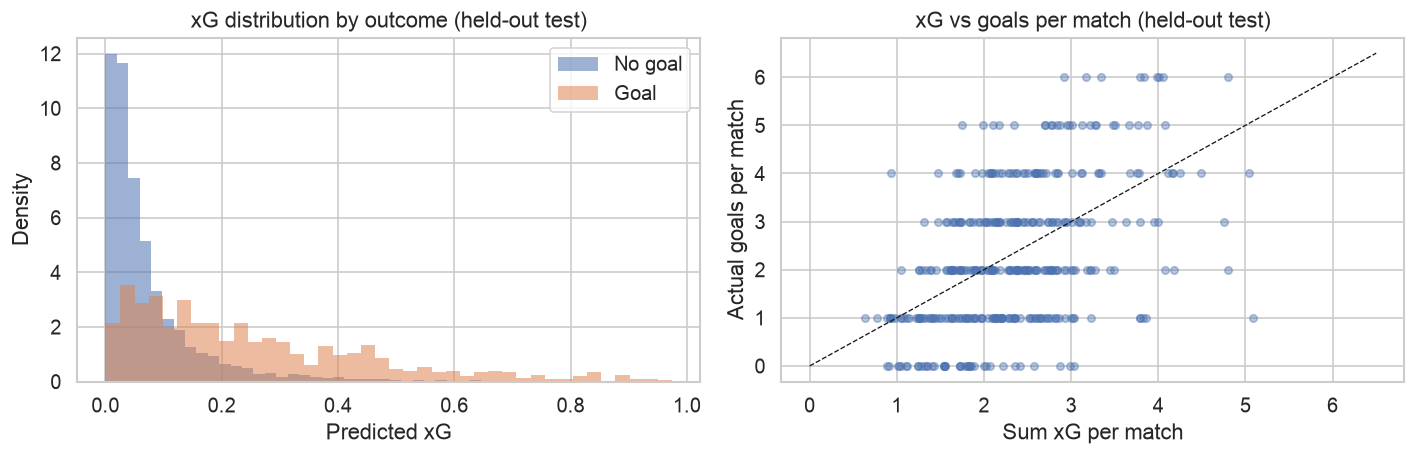

Match-level Pearson r (xG vs goals, held-out test): 0.489


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for outcome, label, color in [(0, 'No goal', '#4C72B0'), (1, 'Goal', '#DD8452')]:
    axes[0].hist(test_proba[y_test == outcome], bins=40, alpha=0.55,
                 label=label, color=color, density=True, edgecolor='none')
axes[0].set_xlabel('Predicted xG')
axes[0].set_ylabel('Density')
axes[0].set_title('xG distribution by outcome (held-out test)')
axes[0].legend()

shots_eval = shots_test.copy()
shots_eval['xg'] = test_proba
match_summary = shots_eval.groupby('match_id').agg(
    xG_total=('xg', 'sum'),
    actual_goals=('is_goal', 'sum'),
)
axes[1].scatter(match_summary['xG_total'], match_summary['actual_goals'],
                alpha=0.4, s=20, color='#4C72B0')
lim = max(match_summary[['xG_total', 'actual_goals']].max()) + 0.5
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=0.8)
axes[1].set_xlabel('Sum xG per match')
axes[1].set_ylabel('Actual goals per match')
axes[1].set_title('xG vs goals per match (held-out test)')

plt.tight_layout()
plt.show()

match_corr = match_summary.corr().loc['xG_total', 'actual_goals']
print(f"Match-level Pearson r (xG vs goals, held-out test): {match_corr:.3f}")

## 9. Results Summary

In [29]:
print("="*45)
print(" Ridge Logistic Regression xG Model")
print("="*45)
print(f" Train shots:   {len(shots_train):,} ({train_labels})")
print(f" Test shots:    {len(shots_test):,} ({HOLDOUT_LABEL}, held out)")
print(f" Goal rate:     {y_test.mean():.1%} (held-out test)")
print(f" Features:      {len(ALL_FEATURE_NAMES)} (after encoding)")
print(f" Best C:        {best_C:.5f}")
print(f" CV folds:      5-fold stratified (training set only)")
print("-"*45)
print(" Training CV (OOF) vs held-out test:")
print(comparison_cv_test.to_string())
print("-"*45)
print(" Held-out test — full model (all features):")
for name, val in metrics.items():
    print(f"   {name:<15} {val:.4f}")
print(f"   {'ECE':<15} {ece:.4f}")
print("-"*45)
print(" Held-out test — baseline (distance + angle only):")
for name, val in baseline_metrics.items():
    print(f"   {name:<15} {val:.4f}")
print("-"*45)
#print(f" Model saved:   {model_path}")
print("="*45)

 Ridge Logistic Regression xG Model
 Train shots:   20,347 (La Liga 2015/16, Champions League 2018/19, Premier League 2015/16, World Cup 2022)
 Test shots:    9,877 (Serie A 2015/16, held out)
 Goal rate:     8.7% (held-out test)
 Features:      54 (after encoding)
 Best C:        0.20857
 CV folds:      5-fold stratified (training set only)
---------------------------------------------
 Training CV (OOF) vs held-out test:
             Training CV (OOF)  Held-out test (Serie A 2015/16)
ROC-AUC                 0.8035                           0.8181
Log-loss                0.2607                           0.2329
Brier score             0.0742                           0.0650
---------------------------------------------
 Held-out test — full model (all features):
   ROC-AUC         0.8181
   Log-loss        0.2329
   Brier score     0.0650
   ECE             0.0071
---------------------------------------------
 Held-out test — baseline (distance + angle only):
   ROC-AUC         0.7619
